# Install Library


In [1]:
!pip -q install xgboost joblib scipy

ERROR: Exception:
Traceback (most recent call last):
  File "/Users/auliasm17_/opt/anaconda3/lib/python3.8/site-packages/pip/_internal/cli/base_command.py", line 106, in _run_wrapper
    status = _inner_run()
  File "/Users/auliasm17_/opt/anaconda3/lib/python3.8/site-packages/pip/_internal/cli/base_command.py", line 97, in _inner_run
    return self.run(options, args)
  File "/Users/auliasm17_/opt/anaconda3/lib/python3.8/site-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
  File "/Users/auliasm17_/opt/anaconda3/lib/python3.8/site-packages/pip/_internal/commands/install.py", line 484, in run
    installed_versions[distribution.canonical_name] = distribution.version
  File "/Users/auliasm17_/opt/anaconda3/lib/python3.8/site-packages/pip/_internal/metadata/pkg_resources.py", line 192, in version
    return parse_version(self._dist.version)
  File "/Users/auliasm17_/opt/anaconda3/lib/python3.8/site-packages/pip/_vendor/packaging/version

# Import Library


In [2]:
from pathlib import Path
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from IPython.display import display
from scipy.stats import spearmanr

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    make_scorer
)
from sklearn.inspection import permutation_importance

from xgboost import XGBRegressor

from sklearn.model_selection import (
    KFold,
    RandomizedSearchCV
)


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


# Load Data

In [3]:
DATA_DIR = Path("../../data/gold").resolve()
PD_PATH = DATA_DIR / "abt_lgd_sumber.parquet"
DICT_PATH = DATA_DIR / "abt_lgd.parquet"

source = pd.read_parquet(PD_PATH)
test = pd.read_parquet(DICT_PATH)

print("source shape :", source.shape)
print("test shape  :", test.shape)
display(source.head())

source shape : (156824, 12)
test shape  : (214, 25)


,sba_loan_nr,ApprovalFY,app_tenor_bulan,app_jenis_fasilitas,app_revolving,app_sektor_kbli,app_skala_pegawai,app_perusahaan_baru,app_dokumen_ringkas,app_porsi_penjaminan,y_lgd_realisasi,split
0,1000093009,1980,45,investasi,False,G,menengah,False,False,0.8333,0.3483,latih
1,1000554001,1997,137,investasi,False,G,mikro,True,True,0.8000,0.2997,latih
2,1000653000,1980,120,modal_kerja,True,G,kecil,False,False,0.7500,0.2247,latih
3,1000726007,2006,167,investasi,False,F,kecil,True,False,0.7500,0.7730,latih
4,1000735003,1997,7,investasi,False,R,kecil,True,False,0.5000,0.9394,latih


# Data Audit

In [4]:
def audit_data(df):
    return pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_pct": df.isna().mean() * 100,
        "n_unique": df.nunique(dropna=False)
    }).sort_values(["missing_pct", "n_unique"], ascending=[False, True])

print("=== SOURCE AUDIT ===")
display(audit_data(source))

print("=== TEST AUDIT ===")
display(audit_data(test))


=== SOURCE AUDIT ===


,dtype,missing,missing_pct,n_unique
app_jenis_fasilitas,object,0,0.0000,2
app_revolving,bool,0,0.0000,2
app_perusahaan_baru,bool,0,0.0000,2
app_dokumen_ringkas,bool,0,0.0000,2
split,object,0,0.0000,2
app_skala_pegawai,string,0,0.0000,5
app_sektor_kbli,object,0,0.0000,18
ApprovalFY,object,0,0.0000,49
app_tenor_bulan,int64,0,0.0000,351
app_porsi_penjaminan,Float64,0,0.0000,1546


=== TEST AUDIT ===


,dtype,missing,missing_pct,n_unique
app_dokumen_ringkas,bool,0,0.0000,2
app_perusahaan_baru,bool,0,0.0000,2
app_jenis_fasilitas,object,0,0.0000,2
app_revolving,bool,0,0.0000,2
app_skala_pegawai,string,0,0.0000,3
app_jumlah_agunan,int64,0,0.0000,3
app_produk_id,int64,0,0.0000,5
app_rating_internal,object,0,0.0000,7
app_porsi_penjaminan,Float64,0,0.0000,9
kbli_kategori,object,0,0.0000,16


# Target Definition dan Distribution

In [5]:
TARGET = "y_lgd_realisasi"

assert TARGET in source.columns, f"{TARGET} tidak ada di source"
assert TARGET in test.columns, f"{TARGET} tidak ada di test"

print("SOURCE TARGET")
display(source[TARGET].describe())

print("\nTEST TARGET")
display(test[TARGET].describe())

print("\nTarget range source:", (source[TARGET].min(), source[TARGET].max()))
print("Target range test  :", (test[TARGET].min(), test[TARGET].max()))


SOURCE TARGET


count   156,824.0000
mean          0.6189
std           0.2652
min           0.0000
25%           0.4087
50%           0.6357
75%           0.8566
max           1.0000
Name: y_lgd_realisasi, dtype: float64


TEST TARGET


count   214.0000
mean      0.6378
std       0.2465
min       0.0966
25%       0.4377
50%       0.6467
75%       0.8746
max       1.0000
Name: y_lgd_realisasi, dtype: float64


Target range source: (0.0, 1.0)
Target range test  : (0.0966, 1.0)


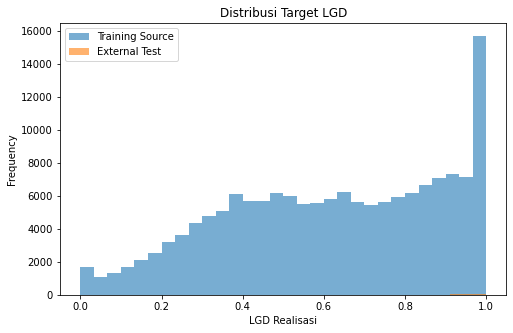

In [6]:
# Visualisasi distribusi target
plt.figure(figsize=(8, 5))
plt.hist(source[TARGET].dropna(), bins=30, alpha=0.6, label="Training Source")
plt.hist(test[TARGET].dropna(), bins=20, alpha=0.6, label="External Test")
plt.xlabel("LGD Realisasi")
plt.ylabel("Frequency")
plt.title("Distribusi Target LGD")
plt.legend()
plt.show()


In [7]:
source = source.drop(columns=["split"], errors="ignore")
test = test.drop(columns=["split"], errors="ignore")

print("Kolom split sudah diabaikan.")


Kolom split sudah diabaikan.


# Leakage Check
`abt_lgd` digunakan sebagai external test. Jika loan yang sama ada di source training, loan tersebut harus dikeluarkan dari training.

In [9]:
SOURCE_ID = "sba_loan_nr"
TEST_SOURCE_ID = "src_sba_loannr"

assert SOURCE_ID in source.columns, f"{SOURCE_ID} tidak ada di source"
assert TEST_SOURCE_ID in test.columns, f"{TEST_SOURCE_ID} tidak ada di test"

source_ids = set(source[SOURCE_ID].dropna())
test_ids = set(test[TEST_SOURCE_ID].dropna())

overlap_ids = source_ids.intersection(test_ids)

print("Jumlah source loan :", len(source_ids))
print("Jumlah test loan   :", len(test_ids))
print("Jumlah overlap     :", len(overlap_ids))


Jumlah source loan : 156824
Jumlah test loan   : 214
Jumlah overlap     : 214


In [10]:
target_compare = (
    test[[TEST_SOURCE_ID, TARGET]]
    .merge(
        source[[SOURCE_ID, TARGET]],
        left_on=TEST_SOURCE_ID,
        right_on=SOURCE_ID,
        how="inner",
        suffixes=("_test", "_source")
    )
)

if len(target_compare) > 0:
    corr = target_compare[[f"{TARGET}_test", f"{TARGET}_source"]].corr().iloc[0, 1]
    max_abs_diff = np.abs(
        target_compare[f"{TARGET}_test"] - target_compare[f"{TARGET}_source"]
    ).max()

    print("Matched rows               :", len(target_compare))
    print("Target correlation         :", corr)
    print("Maximum target abs diff    :", max_abs_diff)
else:
    print("Tidak ada overlap ID.")

Matched rows               : 214
Target correlation         : 0.703467021910344
Maximum target abs diff    : 0.4805942558746737


# Remove External Test Loans from Training

In [11]:
train = source[
    ~source[SOURCE_ID].isin(test_ids)
].copy()

print("Training awal :", len(source))
print("Overlap       :", len(source) - len(train))
print("Training final:", len(train))
print("External test :", len(test))

assert len(set(train[SOURCE_ID].dropna()).intersection(test_ids)) == 0,     "Masih terdapat overlap antara training dan external test."


Training awal : 156824
Overlap       : 214
Training final: 156610
External test : 214


# Feature Mapping
Hanya predictor yang tersedia secara konsisten pada training source dan external test yang digunakan.

`app_tenor_bulan` pada source dipetakan ke `app_tenor_bulan_sba` pada external test.

In [17]:
FEATURES = [
    "app_tenor_bulan",
    "app_porsi_penjaminan",
    "app_jenis_fasilitas",
    "app_sektor_kbli",
    "app_skala_pegawai",
    "app_perusahaan_baru",
    "app_dokumen_ringkas",
]

NUM_FEATURES = [
    "app_tenor_bulan",
    "app_porsi_penjaminan",
]

CAT_FEATURES = [
    "app_jenis_fasilitas",
    "app_sektor_kbli",
    "app_skala_pegawai",
    "app_perusahaan_baru",
    "app_dokumen_ringkas",
]

missing_train_cols = [c for c in FEATURES if c not in train.columns]
missing_test_cols = [c for c in FEATURES if c not in test.columns]

assert not missing_train_cols, f"Missing training features: {missing_train_cols}"
assert not missing_test_cols, f"Missing test features: {missing_test_cols}"

print("Training features:", FEATURES)
print("Semua feature mapping tersedia.")


Training features: ['app_tenor_bulan', 'app_porsi_penjaminan', 'app_jenis_fasilitas', 'app_sektor_kbli', 'app_skala_pegawai', 'app_perusahaan_baru', 'app_dokumen_ringkas']
Semua feature mapping tersedia.


# Prepare Training & External Test

In [21]:
X = train[FEATURES].copy()
y = train[TARGET].astype(float).copy()

X_test = test[FEATURES].copy()

y_test = test[TARGET].astype(float).copy()

# Categorical disamakan menjadi string agar preprocessing konsisten.
for col in CAT_FEATURES:
    X[col] = X[col].astype(str)
    X_test[col] = X_test[col].astype(str)

print("X train :", X.shape)
print("y train :", y.shape)
print("X test  :", X_test.shape)
print("y test  :", y_test.shape)


X train : (156610, 7)
y train : (156610,)
X test  : (214, 7)
y test  : (214,)


# Data Quality pada Final Feature

In [22]:
feature_quality = pd.DataFrame({
    "train_missing": X.isna().sum(),
    "train_missing_pct": X.isna().mean() * 100,
    "test_missing": X_test.isna().sum(),
    "test_missing_pct": X_test.isna().mean() * 100,
    "train_unique": X.nunique(dropna=False),
    "test_unique": X_test.nunique(dropna=False),
})

display(feature_quality)


,train_missing,train_missing_pct,test_missing,test_missing_pct,train_unique,test_unique
app_tenor_bulan,0,0.0000,0,0.0000,351,88
app_porsi_penjaminan,0,0.0000,0,0.0000,1545,9
app_jenis_fasilitas,0,0.0000,0,0.0000,2,2
app_sektor_kbli,0,0.0000,0,0.0000,18,16
app_skala_pegawai,0,0.0000,0,0.0000,5,3
app_perusahaan_baru,0,0.0000,0,0.0000,2,2
app_dokumen_ringkas,0,0.0000,0,0.0000,2,2


In [23]:
# Check unseen categories pada external test
for col in CAT_FEATURES:
    train_categories = set(X[col].dropna().unique())
    test_categories = set(X_test[col].dropna().unique())
    unseen = test_categories - train_categories

    print(f"{col:25s} unseen categories in test: {sorted(unseen)[:10]}")


app_jenis_fasilitas       unseen categories in test: []
app_sektor_kbli           unseen categories in test: []
app_skala_pegawai         unseen categories in test: []
app_perusahaan_baru       unseen categories in test: []
app_dokumen_ringkas       unseen categories in test: []


# Internal Train/Validation Split

External test **tidak digunakan** untuk memilih model atau hyperparameter.

Source-clean dibagi menjadi development train dan validation.

In [24]:
# Stratification berdasarkan decile target supaya distribusi LGD tetap representatif.
target_bins = pd.qcut(
    y,
    q=10,
    labels=False,
    duplicates="drop"
)

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=target_bins
)

print("Development train:", X_train.shape)
print("Validation       :", X_val.shape)
print("External test    :", X_test.shape)


Development train: (125288, 7)
Validation       : (31322, 7)
External test    : (214, 7)


# Preprocessing Pipeline

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            CAT_FEATURES
        ),
        (
            "numeric",
            "passthrough",
            NUM_FEATURES
        )
    ],
    remainder="drop"
)

print(preprocessor)


ColumnTransformer(transformers=[('categorical',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['app_jenis_fasilitas', 'app_sektor_kbli',
                                  'app_skala_pegawai', 'app_perusahaan_baru',
                                  'app_dokumen_ringkas']),
                                ('numeric', 'passthrough',
                                 ['app_tenor_bulan', 'app_porsi_penjaminan'])])


# Evaluation Function

In [ ]:
import numpy as np
from scipy.stats import spearmanr
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def regression_metrics_local(
    y_true,
    y_pred
):

    y_true = np.asarray(
        y_true,
        dtype=float
    )

    y_pred = np.asarray(
        y_pred,
        dtype=float
    )


    return {
        "MAE":
            float(
                mean_absolute_error(
                    y_true,
                    y_pred
                )
            ),

        "MSE":
            float(
                mean_squared_error(
                    y_true,
                    y_pred
                )
            ),

        "RMSE":
            float(
                np.sqrt(
                    mean_squared_error(
                        y_true,
                        y_pred
                    )
                )
            ),

        "R2":
            float(
                r2_score(
                    y_true,
                    y_pred
                )
            ),

        "Bias":
            float(
                np.mean(
                    y_pred - y_true
                )
            )
    }

# Mean Baseline

In [28]:
baseline_pred_val = np.repeat(y_train.mean(), len(y_val))

baseline_val_metrics = regression_metrics_local(
    y_val,
    baseline_pred_val
)

print("VALIDATION BASELINE")
display(pd.DataFrame([baseline_val_metrics]))


VALIDATION BASELINE


,MAE,MSE,RMSE,R2,Bias
0,0.2269,0.0702,0.2649,-0.0000,-0.0000


# Candidate Models

In [30]:
# ============================================================
# COMPARE: LINEAR REGRESSION vs RIDGE vs XGBOOST
# ============================================================

import numpy as np
import pandas as pd

from scipy.stats import spearmanr

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

# ============================================================
# 2. PREPROCESSING
# ============================================================

# Linear & Ridge:
# numeric -> impute + scaling
# categorical -> impute + one-hot encoding

linear_preprocessor = ColumnTransformer(
    transformers=[
        
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            NUM_FEATURES
        ),
        
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(
                    handle_unknown="ignore",
                    drop="first"
                ))
            ]),
            CAT_FEATURES
        )
    ]
)


# XGBoost tidak perlu scaling
xgb_preprocessor = ColumnTransformer(
    transformers=[
        
        (
            "num",
            SimpleImputer(strategy="median"),
            NUM_FEATURES
        ),
        
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            CAT_FEATURES
        )
    ]
)


# ============================================================
# 3. DEFINE MODELS
# ============================================================

models = {
    
    "Linear Regression": Pipeline([
        ("preprocessor", linear_preprocessor),
        ("model", LinearRegression())
    ]),
    
    
    "Ridge Regression": Pipeline([
        ("preprocessor", linear_preprocessor),
        ("model", Ridge(
            alpha=1.0,
            solver="lsqr"
        ))
    ]),
    
    
    "XGBoost": Pipeline([
        ("preprocessor", xgb_preprocessor),
        ("model", XGBRegressor(
            
            objective="reg:squarederror",
            
            n_estimators=900,
            learning_rate=0.03,
            
            max_depth=5,
            min_child_weight=30,
            
            subsample=0.9,
            colsample_bytree=0.9,
            
            reg_lambda=30,
            reg_alpha=0.3,
            
            random_state=42,
            n_jobs=-1,
            tree_method="hist"
        ))
    ])
}


# ============================================================
# 4. TRAIN + VALIDATION + EVALUATION
# ============================================================

results = []
predictions = {}

for name, model in models.items():
    
    print(f"Training {name}...")
    
    # Train
    model.fit(
        X_train,
        y_train
    )
    
    # Predict validation
    y_pred = model.predict(
        X_val
    )
    
    # LGD harus 0 - 1
    y_pred = np.clip(
        y_pred,
        0,
        1
    )
    
    predictions[name] = y_pred
    
    # Evaluation
    metrics = regression_metrics_local(
        y_val,
        y_pred
    )
    
    results.append({
        "Model": name,
        **metrics
    })


# ============================================================
# 5. MODEL COMPARISON
# ============================================================

comparison_df = pd.DataFrame(
    results
).sort_values(
    by="MSE",
    ascending=True
).reset_index(
    drop=True
)

display(comparison_df)


# ============================================================
# 6. CHAMPION MODEL
# ============================================================

best_model_name = comparison_df.iloc[0]["Model"]

print("=" * 60)
print("CHAMPION MODEL :", best_model_name)
print("=" * 60)

print(
    f"MAE      : {comparison_df.iloc[0]['MAE']:.4f}"
)

print(
    f"MSE      : {comparison_df.iloc[0]['MSE']:.4f}"
)

print(
    f"RMSE     : {comparison_df.iloc[0]['RMSE']:.4f}"
)

print(
    f"R²       : {comparison_df.iloc[0]['R2']:.4f}"
)

print(
    f"Spearman : {comparison_df.iloc[0]['Spearman']:.4f}"
)

print(
    f"Bias     : {comparison_df.iloc[0]['Bias']:.4f}"
)

Training Linear Regression...
Training Ridge Regression...
Training XGBoost...


,Model,MAE,MSE,RMSE,R2,Bias
0,XGBoost,0.1711,0.0481,0.2194,0.3139,0.0007
1,Ridge Regression,0.2094,0.0644,0.2538,0.0815,-0.0004
2,Linear Regression,0.2094,0.0644,0.2539,0.0814,-0.0004


CHAMPION MODEL : XGBoost
MAE      : 0.1711
MSE      : 0.0481
RMSE     : 0.2194
R²       : 0.3139


KeyError: 'Spearman'

# Hyperparameter Tuning XGBoost

In [31]:

# ============================================================
# 2. BASE XGBOOST
# ============================================================

xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    tree_method="hist",
    
    # dibuat 1 supaya tidak oversubscribe
    # karena RandomizedSearchCV sudah parallel
    n_jobs=1
)


pipeline = Pipeline([
    (
        "preprocessor",
        xgb_preprocessor
    ),
    (
        "model",
        xgb
    )
])


# ============================================================
# 3. PARAMETER SPACE
# ============================================================

param_distributions = {

    "model__n_estimators": [
        300,
        500,
        700,
        900,
        1200
    ],

    "model__learning_rate": [
        0.01,
        0.03,
        0.05,
        0.08,
        0.10
    ],

    "model__max_depth": [
        3,
        4,
        5,
        6,
        7
    ],

    "model__min_child_weight": [
        5,
        10,
        20,
        30,
        50
    ],

    "model__subsample": [
        0.7,
        0.8,
        0.9,
        1.0
    ],

    "model__colsample_bytree": [
        0.7,
        0.8,
        0.9,
        1.0
    ],

    "model__reg_alpha": [
        0,
        0.1,
        0.3,
        0.5,
        1.0
    ],

    "model__reg_lambda": [
        1,
        5,
        10,
        20,
        30,
        50
    ],

    "model__gamma": [
        0,
        0.01,
        0.05,
        0.1,
        0.2
    ]
}


# ============================================================
# 4. CUSTOM SCORER
# LGD prediction di-clip antara 0 dan 1
# ============================================================

def clipped_mae(y_true, y_pred):
    
    y_pred = np.clip(
        y_pred,
        0,
        1
    )
    
    return mean_absolute_error(
        y_true,
        y_pred
    )


mae_scorer = make_scorer(
    clipped_mae,
    greater_is_better=False
)


# ============================================================
# 5. CROSS VALIDATION
# ============================================================

cv = KFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)


# ============================================================
# 6. RANDOMIZED SEARCH
# ============================================================

random_search = RandomizedSearchCV(

    estimator=pipeline,

    param_distributions=
        param_distributions,

    # jumlah kombinasi random
    n_iter=25,

    scoring=mae_scorer,

    cv=cv,

    verbose=2,

    random_state=42,

    n_jobs=-1,

    return_train_score=True
)


# ============================================================
# 7. TUNING
# HANYA menggunakan development training
# ============================================================

random_search.fit(
    X_train,
    y_train
)


# ============================================================
# 8. BEST PARAMETER
# ============================================================

print("=" * 70)
print("BEST XGBOOST PARAMETERS")
print("=" * 70)

for param, value in random_search.best_params_.items():
    print(
        f"{param}: {value}"
    )


print()
print(
    "Best CV MAE:",
    -random_search.best_score_
)


# ============================================================
# 9. BEST MODEL
# ============================================================

best_xgb = random_search.best_estimator_


# ============================================================
# 10. VALIDATION PREDICTION
# ============================================================

val_pred_tuned = best_xgb.predict(
    X_val
)


# LGD harus 0 - 1

val_pred_tuned = np.clip(
    val_pred_tuned,
    0,
    1
)

# ============================================================
# 11. VALIDATION METRICS
# ============================================================

mae = mean_absolute_error(
    y_val,
    val_pred_tuned
)

mse = mean_squared_error(
        y_val,
        val_pred_tuned
    )

rmse = np.sqrt(
    mean_squared_error(
        y_val,
        val_pred_tuned
    )
)

r2 = r2_score(
    y_val,
    val_pred_tuned
)

bias = np.mean(
    val_pred_tuned
    -
    np.asarray(y_val)
)


tuned_metrics = pd.DataFrame({

    "Model": [
        "Tuned XGBoost"
    ],

    "MAE": [
        mae
    ],

    "MSE": [
        mse
    ],

    "RMSE": [
        rmse
    ],

    "R2": [
        r2
    ],

    "Bias": [
        bias
    ]

})


print()
print("=" * 70)
print("TUNED XGBOOST - VALIDATION PERFORMANCE")
print("=" * 70)

display(
    tuned_metrics
)

Fitting 3 folds for each of 25 candidates, totalling 75 fits
BEST XGBOOST PARAMETERS
model__subsample: 1.0
model__reg_lambda: 5
model__reg_alpha: 1.0
model__n_estimators: 700
model__min_child_weight: 50
model__max_depth: 6
model__learning_rate: 0.05
model__gamma: 0
model__colsample_bytree: 0.9

Best CV MAE: 0.17247926683687972

TUNED XGBOOST - VALIDATION PERFORMANCE


,Model,MAE,MSE,RMSE,R2,Bias
0,Tuned XGBoost,0.1710,0.0482,0.2196,0.3123,0.0006


In [33]:
# ============================================================
# BEFORE vs AFTER TUNING
# ============================================================

tuning_comparison = pd.DataFrame([

    {
        "Model":
            "XGBoost Before Tuning",

        **regression_metrics_local(
            y_val,
            y_pred
        )
    },

    {
        "Model":
            "XGBoost After Tuning",

        **regression_metrics_local(
            y_val,
            val_pred_tuned
        )
    }

]).sort_values(
    "MSE"
)


display(
    tuning_comparison
)

,Model,MAE,MSE,RMSE,R2,Bias
0,XGBoost Before Tuning,0.1711,0.0481,0.2194,0.3139,0.0007
1,XGBoost After Tuning,0.1710,0.0482,0.2196,0.3123,0.0006


In [34]:
# ============================================================
# GET ALL PARAMETERS FROM XGBOOST BEFORE TUNING
# ============================================================

xgb_before_params = (
    models["XGBoost"]
    .named_steps["model"]
    .get_params()
)

xgb_before_params

{'objective': 'reg:squarederror',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': 0.9,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.03,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 5,
 'max_leaves': None,
 'min_child_weight': 30,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 900,
 'n_jobs': -1,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': 0.3,
 'reg_lambda': 30,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': 0.9,
 'tree_method': 'hist',
 'validate_parameters': None,
 'verbosity': None}

In [35]:
# ============================================================
# GET SELECTED XGBOOST BEFORE-TUNING PARAMETERS
# ============================================================

param_names = [
    "n_estimators",
    "learning_rate",
    "max_depth",
    "min_child_weight",
    "subsample",
    "colsample_bytree",
    "reg_lambda",
    "reg_alpha",
    "objective",
    "tree_method",
    "random_state",
    "n_jobs"
]

all_xgb_before_params = (
    models["XGBoost"]
    .named_steps["model"]
    .get_params()
)

xgb_before_params = {
    param: all_xgb_before_params[param]
    for param in param_names
}

xgb_before_params

{'n_estimators': 900,
 'learning_rate': 0.03,
 'max_depth': 5,
 'min_child_weight': 30,
 'subsample': 0.9,
 'colsample_bytree': 0.9,
 'reg_lambda': 30,
 'reg_alpha': 0.3,
 'objective': 'reg:squarederror',
 'tree_method': 'hist',
 'random_state': 42,
 'n_jobs': -1}

# Validation Diagnostic

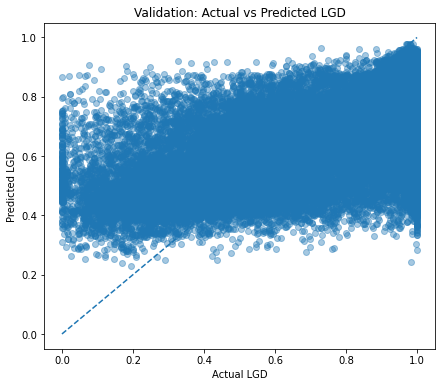

In [36]:
plt.figure(figsize=(7, 6))
plt.scatter(y_val, y_pred, alpha=0.4)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Actual LGD")
plt.ylabel("Predicted LGD")
plt.title("Validation: Actual vs Predicted LGD")
plt.show()


# Permutation Feature Importance

Feature importance dihitung pada validation set, bukan external test, supaya external test tetap berfungsi sebagai final unbiased evaluation.

In [37]:
# Sampling agar proses permutation importance tetap ringan.
n_importance = min(10000, len(X_val))
sample_idx = X_val.sample(
    n=n_importance,
    random_state=RANDOM_STATE
).index

importance = permutation_importance(
    model,
    X_val.loc[sample_idx],
    y_val.loc[sample_idx],
    scoring="neg_root_mean_squared_error",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": FEATURES,
    "importance": importance.importances_mean,
    "importance_std": importance.importances_std
}).sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

display(importance_df)


,feature,importance,importance_std
0,app_tenor_bulan,0.0608,0.0007
1,app_porsi_penjaminan,0.0324,0.0009
2,app_jenis_fasilitas,0.0254,0.0006
3,app_sektor_kbli,0.0040,0.0004
4,app_skala_pegawai,0.0014,0.0001
5,app_dokumen_ringkas,0.0009,0.0001
6,app_perusahaan_baru,0.0004,0.0001


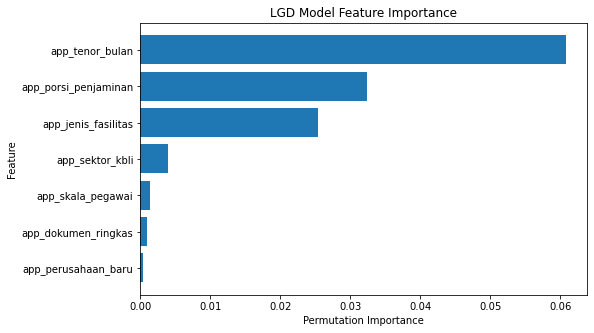

In [38]:
plt.figure(figsize=(8, 5))
plt.barh(
    importance_df["feature"][::-1],
    importance_df["importance"][::-1]
)
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("LGD Model Feature Importance")
plt.show()

# Refit Final Model

Setelah model dan hyperparameter dipilih pada validation, model difit ulang menggunakan **seluruh source-clean training data**.

In [40]:
final_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            CAT_FEATURES
        ),
        (
            "numeric",
            "passthrough",
            NUM_FEATURES
        )
    ],
    remainder="drop"
)

final_model = Pipeline(
    steps=[
        ("preprocessor", final_preprocessor),
        (
            "model",
            XGBRegressor(
                objective="reg:squarederror",
                n_estimators=900,
                 learning_rate=0.03,
                            
                max_depth=5,
                min_child_weight=30,
                            
                subsample=0.9,
                colsample_bytree=0.9,
                            
                reg_lambda=30,
                reg_alpha=0.3,
                            
                random_state=42,
                n_jobs=-1,
                tree_method="hist"
            )
        )
    ]
)

final_model.fit(X, y)

print("Final model selesai direfit menggunakan", len(X), "training rows.")


Final model selesai direfit menggunakan 156610 training rows.


# FINAL EXTERNAL TEST

Sekarang seluruh `abt_lgd` digunakan sebagai external test.
Kolom split tidak digunakan.


In [41]:
test_pred = final_model.predict(X_test)
test_pred = np.clip(test_pred, 0, 1)

final_metrics = regression_metrics_local(
    y_test,
    test_pred
)

print("FINAL EXTERNAL TEST METRICS")
display(pd.DataFrame([final_metrics]))


FINAL EXTERNAL TEST METRICS


,MAE,MSE,RMSE,R2,Bias
0,0.1816,0.0484,0.2199,0.2002,-0.0065


# Compare Against External-Test Mean Baseline


In [42]:
# Baseline harus menggunakan mean training, bukan mean test.
baseline_pred_test = np.repeat(y.mean(), len(y_test))

baseline_test_metrics = regression_metrics_local(
    y_test,
    baseline_pred_test
)

final_comparison = pd.DataFrame([
    {"Model": "Mean Training LGD Baseline", **baseline_test_metrics},
    {"Model": "Final XGBoost", **final_metrics},
])

display(final_comparison)

mae_improvement = (
    (baseline_test_metrics["MAE"] - final_metrics["MAE"])
    / baseline_test_metrics["MAE"]
    * 100
)

rmse_improvement = (
    (baseline_test_metrics["RMSE"] - final_metrics["RMSE"])
    / baseline_test_metrics["RMSE"]
    * 100
)

print(f"MAE improvement  : {mae_improvement:.2f}%")
print(f"RMSE improvement : {rmse_improvement:.2f}%")


,Model,MAE,MSE,RMSE,R2,Bias
0,Mean Training LGD Baseline,0.2144,0.0608,0.2466,-0.0059,-0.0189
1,Final XGBoost,0.1816,0.0484,0.2199,0.2002,-0.0065


MAE improvement  : 15.32%
RMSE improvement : 10.83%


# EAD-Weighted MAE


In [44]:
if "app_ead_rp" in test.columns:
    ead = pd.to_numeric(test["app_ead_rp"], errors="coerce")

    valid_ead = ead.notna() & (ead > 0)

    ead_weighted_mae = np.average(
        np.abs(
            y_test.loc[valid_ead].values
            - test_pred[valid_ead.values]
        ),
        weights=ead.loc[valid_ead].values
    )

    print("EAD Weighted MAE:", ead_weighted_mae)
else:
    ead_weighted_mae = np.nan
    print("Kolom app_ead_rp tidak tersedia.")


EAD Weighted MAE: 0.18894188199106202


# Prediction Result Table


In [45]:
result_cols = [
    c for c in [
        "facility_id",
        "cif_sk",
        "src_sba_loannr",
        "app_ead_rp",
        "app_jenis_fasilitas",
        "app_skala_pegawai",
        TARGET,
    ]
    if c in test.columns
]

result = test[result_cols].copy()

result["pred_lgd"] = test_pred
result["error"] = result["pred_lgd"] - result[TARGET]
result["abs_error"] = np.abs(result["error"])

result = result.sort_values(
    "abs_error",
    ascending=False
).reset_index(drop=True)

display(result.head(20))


,facility_id,cif_sk,src_sba_loannr,app_ead_rp,app_jenis_fasilitas,app_skala_pegawai,y_lgd_realisasi,pred_lgd,error,abs_error
0,992,3763,2919683009,"40,962,000,000.0000",investasi,menengah,0.9877,0.3903,-0.5974,0.5974
1,3163,1041,2830185008,"28,011,000,000.0000",investasi,mikro,0.1107,0.6851,0.5744,0.5744
2,1901,3654,8304754003,"27,954,000,000.0000",modal_kerja,mikro,1.0000,0.5110,-0.4890,0.4890
3,2869,3653,1887065003,"15,843,000,000.0000",modal_kerja,mikro,0.9818,0.4955,-0.4863,0.4863
4,2305,2068,2666535003,"11,339,000,000.0000",investasi,mikro,0.9014,0.4405,-0.4609,0.4609
5,1338,2552,9127794007,"10,891,000,000.0000",investasi,kecil,0.2840,0.7306,0.4466,0.4466
6,1192,1242,1100465002,"26,269,000,000.0000",modal_kerja,mikro,0.9048,0.4701,-0.4347,0.4347
7,211,638,3128302002,"51,189,000,000.0000",investasi,menengah,0.0966,0.5281,0.4315,0.4315
8,3223,2681,2022843004,"36,197,000,000.0000",investasi,kecil,0.9955,0.5664,-0.4291,0.4291
9,3055,476,4933425010,"58,771,000,000.0000",modal_kerja,mikro,0.1651,0.5892,0.4241,0.4241


# Actual vs Predicted — External Test


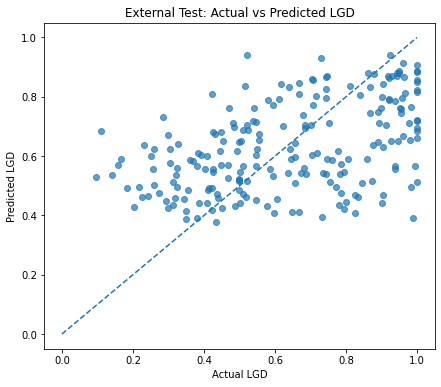

In [46]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, test_pred, alpha=0.7)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Actual LGD")
plt.ylabel("Predicted LGD")
plt.title("External Test: Actual vs Predicted LGD")
plt.show()


# Residual Plot


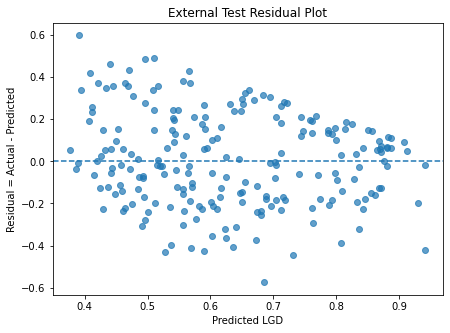

In [47]:
residual = y_test.values - test_pred

plt.figure(figsize=(7, 5))
plt.scatter(test_pred, residual, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted LGD")
plt.ylabel("Residual = Actual - Predicted")
plt.title("External Test Residual Plot")
plt.show()


# Absolute Error Distribution


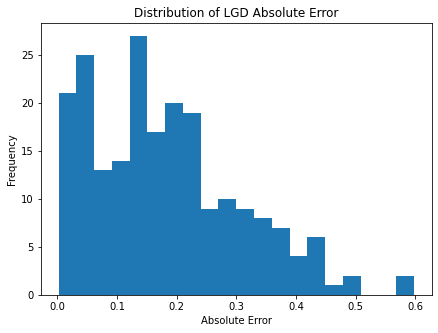

Median Absolute Error: 0.16291642613410945
P90 Absolute Error   : 0.36240757102966326


In [54]:
plt.figure(figsize=(7, 5))
plt.hist(result["abs_error"], bins=20)
plt.xlabel("Absolute Error")
plt.ylabel("Frequency")
plt.title("Distribution of LGD Absolute Error")
plt.show()

print("Median Absolute Error:", result["abs_error"].median())
print("P90 Absolute Error   :", result["abs_error"].quantile(0.90))


# Portfolio Calibration Summary


In [55]:
calibration_summary = pd.DataFrame({
    "Metric": [
        "Actual LGD Mean",
        "Predicted LGD Mean",
        "Portfolio Bias",
        "Actual LGD Median",
        "Predicted LGD Median"
    ],
    "Value": [
        y_test.mean(),
        np.mean(test_pred),
        np.mean(test_pred - y_test.values),
        y_test.median(),
        np.median(test_pred)
    ]
})

display(calibration_summary)


,Metric,Value
0,Actual LGD Mean,0.6378
1,Predicted LGD Mean,0.6313
2,Portfolio Bias,-0.0065
3,Actual LGD Median,0.6467
4,Predicted LGD Median,0.6107


# Segment Performance — Jenis Fasilitas


In [56]:
segment_df = test.copy()
segment_df["pred_lgd"] = test_pred
segment_df["abs_error"] = np.abs(
    segment_df[TARGET] - segment_df["pred_lgd"]
)

if "app_jenis_fasilitas" in segment_df.columns:
    facility_performance = (
        segment_df
        .groupby("app_jenis_fasilitas", dropna=False)
        .agg(
            n=(TARGET, "size"),
            actual_lgd=(TARGET, "mean"),
            pred_lgd=("pred_lgd", "mean"),
            mae=("abs_error", "mean"),
        )
        .reset_index()
        .sort_values("mae")
    )

    display(facility_performance)


,app_jenis_fasilitas,n,actual_lgd,pred_lgd,mae
0,investasi,133,0.6816,0.6841,0.1757
1,modal_kerja,81,0.5658,0.5445,0.1912


# Segment Performance — Skala Pegawai


In [57]:
if "app_skala_pegawai" in segment_df.columns:
    employee_scale_performance = (
        segment_df
        .groupby("app_skala_pegawai", dropna=False)
        .agg(
            n=(TARGET, "size"),
            actual_lgd=(TARGET, "mean"),
            pred_lgd=("pred_lgd", "mean"),
            mae=("abs_error", "mean"),
        )
        .reset_index()
        .sort_values("mae")
    )

    display(employee_scale_performance)


,app_skala_pegawai,n,actual_lgd,pred_lgd,mae
2,mikro,156,0.6538,0.6418,0.1740
0,kecil,47,0.6116,0.6071,0.1972
1,menengah,11,0.5225,0.5856,0.2219


# LGD Risk Band


In [58]:
# Risk band dibuat hanya untuk interpretasi/dashboard.
# Bukan target modeling baru.

def lgd_band(x):
    if x < 0.25:
        return "Low"
    elif x < 0.50:
        return "Medium"
    elif x < 0.75:
        return "High"
    else:
        return "Very High"

result["pred_lgd_band"] = result["pred_lgd"].apply(lgd_band)

display(
    result["pred_lgd_band"]
    .value_counts()
    .rename_axis("LGD Band")
    .reset_index(name="Count")
)


,LGD Band,Count
0,High,110
1,Very High,54
2,Medium,50


# Save Final Model


In [53]:
# ============================================================
# FINAL REFIT: TRAIN + TEST
# ============================================================

import joblib
import pandas as pd

from sklearn.base import clone


# ============================================================
# 1. COMBINE TRAIN + TEST
# ============================================================

X_full = pd.concat(
    [
        X_train,
        X_test
    ],
    axis=0
).reset_index(drop=True)

y_full = pd.concat(
    [
        y_train,
        y_test
    ],
    axis=0
).reset_index(drop=True)


print("Train rows :", len(X_train))
print("Test rows  :", len(X_test))
print("Full rows  :", len(X_full))


# ============================================================
# 2. GET CHAMPION MODEL
#    XGBOOST BEFORE TUNING
# ============================================================

final_model = clone(
    models["XGBoost"]
)


# ============================================================
# 3. REFIT USING ALL AVAILABLE LABELED DATA
# ============================================================

final_model.fit(
    X_full,
    y_full
)

print("Final model fitted on all data.")


# ============================================================
# 4. SAVE FINAL PRODUCTION MODEL
# ============================================================

MODEL_PATH = "final_lgd_xgboost_new.pkl"

artifact = {
    
    "model": final_model,
    
    "features": FEATURES,
    
    "numeric_features": NUM_FEATURES,
    
    "categorical_features": CAT_FEATURES,
    
    "test_feature_mapping": FEATURES,
    
    "target": TARGET,
    
    "champion_model": "XGBoost Before Tuning",
    
    "training_rows": len(X_full),
}


joblib.dump(
    artifact,
    MODEL_PATH
)


print("=" * 60)
print("FINAL LGD MODEL SAVED")
print("=" * 60)

print("Model        :", MODEL_PATH)
print("Champion     : XGBoost Before Tuning")
print("Training rows:", len(X_full))

Train rows : 125288
Test rows  : 214
Full rows  : 125502
Final model fitted on all data.
FINAL LGD MODEL SAVED
Model        : final_lgd_xgboost_new.pkl
Champion     : XGBoost Before Tuning
Training rows: 125502


# Save External Test Predictions


In [ ]:
PREDICTION_PATH = "lgd_test_prediction.csv"

result.to_csv(
    PREDICTION_PATH,
    index=False
)

print("Prediction saved:", PREDICTION_PATH)


Prediction saved: lgd_test_prediction.csv


# Scoring Function untuk Data Baru


In [ ]:
def predict_lgd(model_bundle, new_data):
    model = model_bundle["model"]
    features = model_bundle["features"]
    cat_features = model_bundle["categorical_features"]

    scoring_data = new_data.copy()

    missing = [c for c in features if c not in scoring_data.columns]
    if missing:
        raise ValueError(f"Missing scoring features: {missing}")

    scoring_data = scoring_data[features].copy()

    for col in cat_features:
        scoring_data[col] = scoring_data[col].astype(str)

    pred = model.predict(scoring_data)
    return np.clip(pred, 0, 1)


# Contoh Scoring


In [ ]:
from pathlib import Path
import joblib

MODEL_PATH = Path("../models/final_lgd_xgboost.pkl").resolve()

print("Working directory:", Path.cwd())
print("Model path:", MODEL_PATH)
print("Model exists:", MODEL_PATH.exists())

model_bundle = joblib.load(MODEL_PATH)

Working directory: /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/notebooks
Model path: /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/models/final_lgd_xgboost.pkl
Model exists: True


In [ ]:
# Contoh: ganti kategori agar sesuai domain/data aktual.
new_application = pd.DataFrame({
    "app_tenor_bulan": [60],
    "app_porsi_penjaminan": [0.75],
    "app_jenis_fasilitas": ["investasi"],
    "app_sektor_kbli": ["G"],
    "app_skala_pegawai": ["mikro"],
    "app_perusahaan_baru": ["False"],
    "app_dokumen_ringkas": ["False"],
})

new_lgd = predict_lgd(
    model_bundle,
    new_application
)

print(f"Predicted LGD: {new_lgd[0]:.2%}")


Predicted LGD: 67.07%


# Expected Loss Integration

Output LGD dapat dikombinasikan dengan PD dan EAD:

\[
Expected\ Loss = PD \times LGD \times EAD
\]

In [ ]:
# Contoh ilustrasi
PD = 0.07
LGD = float(new_lgd[0])
EAD = 20_000_000_000

EXPECTED_LOSS = PD * LGD * EAD

print(f"PD            : {PD:.2%}")
print(f"LGD           : {LGD:.2%}")
print(f"EAD           : Rp{EAD:,.0f}")
print(f"Expected Loss : Rp{EXPECTED_LOSS:,.0f}")


PD            : 7.00%
LGD           : 67.07%
EAD           : Rp20,000,000,000
Expected Loss : Rp939,004,135


# Save All File Github

In [60]:
# ============================================================
# LGD - ONE CELL PRODUCTION ARTIFACT EXPORT
# ============================================================
# Jalankan SETELAH seluruh proses modeling LGD selesai.
#
# Output:
# ml/artifacts/lgd/
#   - lgd_champion.joblib
#   - lgd_metadata.json
#   - lgd_feature_schema.json
#   - lgd_decision_policy.json
#   - lgd_metrics.json
#   - lgd_feature_importance.csv
#   - lgd_reference_stats.json
#   - lgd_facility_performance.csv (jika tersedia)
#   - lgd_employee_scale_performance.csv (jika tersedia)
#   - lgd_requirements.txt
#   - lgd_manifest.json
#
# ml/inference/
#   - lgd_predictor.py
# ============================================================


# ============================================================
# 0. IMPORT
# ============================================================

from pathlib import Path
import sys
import json
import hashlib
import joblib
import importlib
import importlib.metadata

import numpy as np
import pandas as pd

from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from scipy.stats import spearmanr


print("=" * 80)
print("LGD PRODUCTION ARTIFACT EXPORT")
print("=" * 80)


# ============================================================
# 1. CHECK REQUIRED VARIABLES
# ============================================================

required_variables = [
    "final_model",
    "FEATURES",
    "NUM_FEATURES",
    "CAT_FEATURES",
    "TEST_FEATURE_MAPPING",
    "TARGET",
    "X",
    "y",
    "X_test",
    "y_test"
]


missing_variables = [
    var
    for var in required_variables
    if var not in globals()
]


if missing_variables:

    raise NameError(
        "Variable berikut belum tersedia. "
        "Jalankan proses modeling LGD terlebih dahulu:\n"
        + "\n".join(
            f"- {var}"
            for var in missing_variables
        )
    )


print("✅ Required modeling variables tersedia")


# ============================================================
# 2. CONFIGURATION
# ============================================================

CHAMPION_NAME = "LGD_XGBOOST"
MODEL_VERSION = "1.0.0"

LGD_MIN = 0.0
LGD_MAX = 1.0


LGD_BANDS = {
    "Low": {
        "min": 0.00,
        "max": 0.25
    },
    "Medium": {
        "min": 0.25,
        "max": 0.50
    },
    "High": {
        "min": 0.50,
        "max": 0.75
    },
    "Very High": {
        "min": 0.75,
        "max": 1.00
    }
}


# Ambil hyperparameter langsung dari fitted final model
FINAL_XGB_PARAMS = (
    final_model
    .named_steps["model"]
    .get_params()
)


# Supaya JSON serializable
FINAL_XGB_PARAMS_JSON = {}

for key, value in FINAL_XGB_PARAMS.items():

    if isinstance(
        value,
        (
            str,
            int,
            float,
            bool
        )
    ) or value is None:

        FINAL_XGB_PARAMS_JSON[key] = value

    else:

        FINAL_XGB_PARAMS_JSON[key] = str(value)


print("✅ Configuration siap")


# ============================================================
# 3. DIRECTORY
# ============================================================

# Asumsi notebook berada di:
# ml/notebooks/02_lgd.ipynb

ML_ROOT = Path("..").resolve()

ARTIFACT_DIR = (
    ML_ROOT
    / "artifacts"
    / "lgd"
)

INFERENCE_DIR = (
    ML_ROOT
    / "inference"
)


ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

INFERENCE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print("ML Root       :", ML_ROOT)
print("Artifact Dir  :", ARTIFACT_DIR)
print("Inference Dir :", INFERENCE_DIR)


# ============================================================
# 4. HELPER FUNCTIONS
# ============================================================

def safe_float(value):

    if value is None:
        return None

    try:

        if pd.isna(value):
            return None

    except Exception:
        pass

    return float(value)


def regression_metrics_local(
    y_true,
    y_pred
):

    y_true = np.asarray(
        y_true,
        dtype=float
    )

    y_pred = np.asarray(
        y_pred,
        dtype=float
    )

    return {
        "MAE":
            float(
                mean_absolute_error(
                    y_true,
                    y_pred
                )
            ),

        "MSE":
            float(
                mean_squared_error(
                    y_true,
                    y_pred
                )
            ),

        "RMSE":
            float(
                np.sqrt(
                    mean_squared_error(
                        y_true,
                        y_pred
                    )
                )
            ),

        "R2":
            float(
                r2_score(
                    y_true,
                    y_pred
                )
            ),

        "Bias":
            float(
                np.mean(
                    y_pred - y_true
                )
            )
    }


def lgd_band_local(
    value
):

    if value < 0.25:
        return "Low"

    elif value < 0.50:
        return "Medium"

    elif value < 0.75:
        return "High"

    else:
        return "Very High"


def sha256_file(
    path
):

    sha256 = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        for chunk in iter(
            lambda: f.read(
                1024 * 1024
            ),
            b""
        ):

            sha256.update(
                chunk
            )

    return sha256.hexdigest()


# ============================================================
# 5. FINAL EXTERNAL TEST PREDICTION
# ============================================================

test_pred_raw = (
    final_model
    .predict(
        X_test[
            FEATURES
        ]
    )
)


test_pred = np.clip(
    test_pred_raw,
    LGD_MIN,
    LGD_MAX
)


final_metrics = (
    regression_metrics_local(
        y_test,
        test_pred
    )
)


print("\n✅ Final external-test prediction selesai")

display(
    pd.DataFrame([
        final_metrics
    ])
)


# ============================================================
# 6. MEAN BASELINE
# ============================================================

baseline_pred_test = np.repeat(
    float(y.mean()),
    len(y_test)
)


baseline_test_metrics = (
    regression_metrics_local(
        y_test,
        baseline_pred_test
    )
)


mae_improvement = (
    (
        baseline_test_metrics[
            "MAE"
        ]
        -
        final_metrics[
            "MAE"
        ]
    )
    /
    baseline_test_metrics[
        "MAE"
    ]
    * 100
)


rmse_improvement = (
    (
        baseline_test_metrics[
            "RMSE"
        ]
        -
        final_metrics[
            "RMSE"
        ]
    )
    /
    baseline_test_metrics[
        "RMSE"
    ]
    * 100
)


print(
    f"MAE improvement  : "
    f"{mae_improvement:.2f}%"
)

print(
    f"RMSE improvement : "
    f"{rmse_improvement:.2f}%"
)


# ============================================================
# 7. EAD WEIGHTED MAE
# ============================================================

ead_weighted_mae = None


if (
    "test" in globals()
    and
    "app_ead_rp" in test.columns
):

    ead = pd.to_numeric(
        test["app_ead_rp"],
        errors="coerce"
    )


    valid_ead = (
        ead.notna()
        &
        (ead > 0)
    )


    if valid_ead.sum() > 0:

        ead_weighted_mae = (
            np.average(

                np.abs(
                    y_test.loc[
                        valid_ead
                    ].values
                    -
                    test_pred[
                        valid_ead.values
                    ]
                ),

                weights=
                    ead.loc[
                        valid_ead
                    ].values
            )
        )


print(
    "EAD Weighted MAE:",
    (
        f"{ead_weighted_mae:.6f}"
        if ead_weighted_mae is not None
        else "Tidak tersedia"
    )
)


# ============================================================
# 8. SAVE MAIN MODEL ARTIFACT
# ============================================================

lgd_artifact = {

    "model":
        final_model,

    "champion_name":
        CHAMPION_NAME,

    "model_version":
        MODEL_VERSION,

    "target":
        TARGET,

    "features":
        list(FEATURES),

    "numeric_features":
        list(NUM_FEATURES),

    "categorical_features":
        list(CAT_FEATURES),

    "input_feature_mapping":
        dict(
            TEST_FEATURE_MAPPING
        ),

    "output_min":
        LGD_MIN,

    "output_max":
        LGD_MAX,

    "risk_bands":
        LGD_BANDS
}


LGD_MODEL_PATH = (
    ARTIFACT_DIR
    / "lgd_champion.joblib"
)


joblib.dump(
    lgd_artifact,
    LGD_MODEL_PATH
)


print(
    "\n✅ Saved:",
    LGD_MODEL_PATH
)


# ============================================================
# 9. FEATURE SCHEMA
# ============================================================

feature_schema = {

    "model":
        CHAMPION_NAME,

    "model_version":
        MODEL_VERSION,

    "target":
        TARGET,

    "number_of_features":
        len(FEATURES),

    "features": {},

    "input_aliases": {}
}


# Mapping raw external -> model feature
for raw_col, model_col in (
    TEST_FEATURE_MAPPING.items()
):

    if raw_col != model_col:

        feature_schema[
            "input_aliases"
        ][raw_col] = model_col


for col in FEATURES:

    series = X[col]


    # --------------------------------------------------------
    # Numeric
    # --------------------------------------------------------

    if col in NUM_FEATURES:

        clean = (
            pd.to_numeric(
                series,
                errors="coerce"
            )
            .dropna()
            .astype(float)
        )


        feature_schema[
            "features"
        ][col] = {

            "type":
                "numeric",

            "dtype":
                str(
                    series.dtype
                ),

            "nullable":
                bool(
                    series.isna().any()
                ),

            "min":
                float(
                    clean.min()
                )
                if len(clean)
                else None,

            "max":
                float(
                    clean.max()
                )
                if len(clean)
                else None
        }


    # --------------------------------------------------------
    # Categorical
    # --------------------------------------------------------

    else:

        categories = (
            series
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )


        feature_schema[
            "features"
        ][col] = {

            "type":
                "categorical",

            "dtype":
                str(
                    series.dtype
                ),

            "nullable":
                bool(
                    series.isna().any()
                ),

            "known_categories":
                sorted(
                    categories
                )
        }


FEATURE_SCHEMA_PATH = (
    ARTIFACT_DIR
    / "lgd_feature_schema.json"
)


with open(
    FEATURE_SCHEMA_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        feature_schema,
        f,
        indent=2,
        ensure_ascii=False
    )


print(
    "✅ Saved:",
    FEATURE_SCHEMA_PATH
)


# ============================================================
# 10. DECISION / OUTPUT POLICY
# ============================================================

decision_policy = {

    "model":
        CHAMPION_NAME,

    "model_version":
        MODEL_VERSION,

    "output_name":
        "Loss Given Default",

    "output_definition":
        (
            "Estimated proportion of exposure "
            "that would be lost if default occurs."
        ),

    "valid_range": {
        "minimum": 0.0,
        "maximum": 1.0
    },

    "post_processing": {
        "method":
            "clip",

        "rule":
            "LGD predictions are clipped to [0, 1]"
    },

    "risk_band": {

        "Low":
            "LGD < 0.25",

        "Medium":
            "0.25 <= LGD < 0.50",

        "High":
            "0.50 <= LGD < 0.75",

        "Very High":
            "LGD >= 0.75"
    },

    "risk_band_note":
        (
            "Risk bands are interpretive/dashboard bands "
            "from the modeling notebook, not an official "
            "bank policy threshold."
        )
}


DECISION_POLICY_PATH = (
    ARTIFACT_DIR
    / "lgd_decision_policy.json"
)


with open(
    DECISION_POLICY_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        decision_policy,
        f,
        indent=2,
        ensure_ascii=False
    )


print(
    "✅ Saved:",
    DECISION_POLICY_PATH
)


# ============================================================
# 11. METRICS
# ============================================================

metrics = {

    "model":
        CHAMPION_NAME,

    "model_version":
        MODEL_VERSION,

    "external_test": {
        key.lower():
            safe_float(value)

        for key, value
        in final_metrics.items()
    },

    "mean_training_baseline": {
        key.lower():
            safe_float(value)

        for key, value
        in baseline_test_metrics.items()
    },

    "improvement_vs_baseline": {

        "mae_improvement_pct":
            float(
                mae_improvement
            ),

        "rmse_improvement_pct":
            float(
                rmse_improvement
            )
    },

    "ead_weighted_mae":
        safe_float(
            ead_weighted_mae
        )
}


METRICS_PATH = (
    ARTIFACT_DIR
    / "lgd_metrics.json"
)


with open(
    METRICS_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        metrics,
        f,
        indent=2,
        ensure_ascii=False
    )


print(
    "✅ Saved:",
    METRICS_PATH
)


# ============================================================
# 12. METADATA
# ============================================================

metadata = {

    "model_name":
        "Loss Given Default",

    "champion_name":
        CHAMPION_NAME,

    "model_family":
        "XGBoost Regressor",

    "model_version":
        MODEL_VERSION,

    "problem_type":
        "regression",

    "target":
        TARGET,

    "target_definition":
        "Realized Loss Given Default",

    "output_range":
        [
            0.0,
            1.0
        ],

    "number_of_features":
        int(
            len(FEATURES)
        ),

    "training": {

        "rows":
            int(
                len(X)
            ),

        "target_mean":
            float(
                y.mean()
            ),

        "target_median":
            float(
                y.median()
            )
    },

    "external_test": {

        "rows":
            int(
                len(X_test)
            ),

        "target_mean":
            float(
                y_test.mean()
            ),

        "target_median":
            float(
                y_test.median()
            )
    },

    "features":
        list(
            FEATURES
        ),

    "numeric_features":
        list(
            NUM_FEATURES
        ),

    "categorical_features":
        list(
            CAT_FEATURES
        ),

    "feature_mapping":
        dict(
            TEST_FEATURE_MAPPING
        ),

    "post_processing":
        "clip prediction to [0, 1]",

    "hyperparameters":
        FINAL_XGB_PARAMS_JSON
}


METADATA_PATH = (
    ARTIFACT_DIR
    / "lgd_metadata.json"
)


with open(
    METADATA_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        metadata,
        f,
        indent=2,
        ensure_ascii=False
    )


print(
    "✅ Saved:",
    METADATA_PATH
)


# ============================================================
# 13. FEATURE IMPORTANCE
# ============================================================
# Gunakan importance_df dari notebook jika sudah tersedia.
# Jika belum, hitung dari development model + validation set.
# External test tidak dipakai untuk feature selection.


if "importance_df" in globals():

    lgd_feature_importance = (
        importance_df
        .copy()
    )


    # Samakan nama kolom
    if (
        "importance"
        in lgd_feature_importance.columns
        and
        "importance_mean"
        not in lgd_feature_importance.columns
    ):

        lgd_feature_importance = (
            lgd_feature_importance
            .rename(
                columns={
                    "importance":
                        "importance_mean"
                }
            )
        )


    print(
        "✅ Menggunakan feature importance "
        "yang sudah dihitung di notebook"
    )


elif all(
    var in globals()
    for var in [
        "model",
        "X_val",
        "y_val"
    ]
):

    print(
        "Menghitung permutation feature importance..."
    )


    n_importance = min(
        10000,
        len(X_val)
    )


    sample_idx = (
        X_val
        .sample(
            n=n_importance,
            random_state=
                globals().get(
                    "RANDOM_STATE",
                    42
                )
        )
        .index
    )


    importance_result = (
        permutation_importance(

            model,

            X_val.loc[
                sample_idx
            ],

            y_val.loc[
                sample_idx
            ],

            scoring=
                "neg_root_mean_squared_error",

            n_repeats=5,

            random_state=
                globals().get(
                    "RANDOM_STATE",
                    42
                ),

            n_jobs=-1
        )
    )


    lgd_feature_importance = (
        pd.DataFrame({

            "feature":
                FEATURES,

            "importance_mean":
                importance_result
                .importances_mean,

            "importance_std":
                importance_result
                .importances_std
        })
        .sort_values(
            "importance_mean",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )


else:

    print(
        "⚠️ model / X_val / y_val tidak tersedia."
    )

    print(
        "Feature importance dibuat dari final model "
        "dan external test hanya sebagai fallback."
    )


    importance_result = (
        permutation_importance(

            final_model,

            X_test,

            y_test,

            scoring=
                "neg_root_mean_squared_error",

            n_repeats=5,

            random_state=
                globals().get(
                    "RANDOM_STATE",
                    42
                ),

            n_jobs=-1
        )
    )


    lgd_feature_importance = (
        pd.DataFrame({

            "feature":
                FEATURES,

            "importance_mean":
                importance_result
                .importances_mean,

            "importance_std":
                importance_result
                .importances_std

        })
        .sort_values(
            "importance_mean",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )


FEATURE_IMPORTANCE_PATH = (
    ARTIFACT_DIR
    / "lgd_feature_importance.csv"
)


lgd_feature_importance.to_csv(
    FEATURE_IMPORTANCE_PATH,
    index=False
)


print(
    "✅ Saved:",
    FEATURE_IMPORTANCE_PATH
)

display(
    lgd_feature_importance
)


# ============================================================
# 14. FEATURE REFERENCE STATISTICS
# ============================================================

reference_stats = {}


for col in FEATURES:

    series = X[col]


    # --------------------------------------------------------
    # BOOLEAN
    # --------------------------------------------------------

    if pd.api.types.is_bool_dtype(
        series
    ):

        clean = (
            series
            .dropna()
            .astype(int)
        )


        reference_stats[col] = {

            "type":
                "boolean",

            "count":
                int(
                    len(clean)
                ),

            "missing_count":
                int(
                    series.isna().sum()
                ),

            "true_count":
                int(
                    clean.sum()
                )
                if len(clean)
                else 0,

            "false_count":
                int(
                    (clean == 0).sum()
                )
                if len(clean)
                else 0,

            "true_rate":
                float(
                    clean.mean()
                )
                if len(clean)
                else None
        }


    # --------------------------------------------------------
    # NUMERIC
    # --------------------------------------------------------

    elif col in NUM_FEATURES:

        clean = (
            pd.to_numeric(
                series,
                errors="coerce"
            )
            .dropna()
            .astype(float)
        )


        reference_stats[col] = {

            "type":
                "numeric",

            "count":
                int(
                    len(clean)
                ),

            "missing_count":
                int(
                    series.isna().sum()
                ),

            "mean":
                float(
                    clean.mean()
                )
                if len(clean)
                else None,

            "median":
                float(
                    clean.median()
                )
                if len(clean)
                else None,

            "p25":
                float(
                    clean.quantile(
                        0.25
                    )
                )
                if len(clean)
                else None,

            "p75":
                float(
                    clean.quantile(
                        0.75
                    )
                )
                if len(clean)
                else None,

            "p95":
                float(
                    clean.quantile(
                        0.95
                    )
                )
                if len(clean)
                else None,

            "min":
                float(
                    clean.min()
                )
                if len(clean)
                else None,

            "max":
                float(
                    clean.max()
                )
                if len(clean)
                else None
        }


    # --------------------------------------------------------
    # CATEGORICAL
    # --------------------------------------------------------

    else:

        counts = (
            series
            .astype("string")
            .value_counts(
                dropna=False
            )
            .head(50)
        )


        reference_stats[col] = {

            "type":
                "categorical",

            "count":
                int(
                    series
                    .notna()
                    .sum()
                ),

            "missing_count":
                int(
                    series
                    .isna()
                    .sum()
                ),

            "n_unique":
                int(
                    series.nunique(
                        dropna=True
                    )
                ),

            "top_categories": {

                str(k):
                    int(v)

                for k, v
                in counts.items()
            }
        }


REFERENCE_PATH = (
    ARTIFACT_DIR
    / "lgd_reference_stats.json"
)


with open(
    REFERENCE_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        reference_stats,
        f,
        indent=2,
        ensure_ascii=False
    )


print(
    "✅ Saved:",
    REFERENCE_PATH
)


# ============================================================
# 15. SEGMENT PERFORMANCE
# ============================================================

FACILITY_PATH = (
    ARTIFACT_DIR
    / "lgd_facility_performance.csv"
)


EMPLOYEE_PATH = (
    ARTIFACT_DIR
    / "lgd_employee_scale_performance.csv"
)


if "test" in globals():

    segment_df_export = (
        test.copy()
    )


    segment_df_export[
        "pred_lgd"
    ] = test_pred


    segment_df_export[
        "abs_error"
    ] = np.abs(
        segment_df_export[
            TARGET
        ]
        -
        segment_df_export[
            "pred_lgd"
        ]
    )


    # --------------------------------------------------------
    # Facility
    # --------------------------------------------------------

    if (
        "app_jenis_fasilitas"
        in segment_df_export.columns
    ):

        facility_performance_export = (
            segment_df_export
            .groupby(
                "app_jenis_fasilitas",
                dropna=False
            )
            .agg(
                n=(
                    TARGET,
                    "size"
                ),

                actual_lgd=(
                    TARGET,
                    "mean"
                ),

                pred_lgd=(
                    "pred_lgd",
                    "mean"
                ),

                mae=(
                    "abs_error",
                    "mean"
                )
            )
            .reset_index()
            .sort_values(
                "mae"
            )
        )


        facility_performance_export.to_csv(
            FACILITY_PATH,
            index=False
        )


        print(
            "✅ Saved:",
            FACILITY_PATH
        )


    # --------------------------------------------------------
    # Employee scale
    # --------------------------------------------------------

    if (
        "app_skala_pegawai"
        in segment_df_export.columns
    ):

        employee_scale_performance_export = (
            segment_df_export
            .groupby(
                "app_skala_pegawai",
                dropna=False
            )
            .agg(
                n=(
                    TARGET,
                    "size"
                ),

                actual_lgd=(
                    TARGET,
                    "mean"
                ),

                pred_lgd=(
                    "pred_lgd",
                    "mean"
                ),

                mae=(
                    "abs_error",
                    "mean"
                )
            )
            .reset_index()
            .sort_values(
                "mae"
            )
        )


        employee_scale_performance_export.to_csv(
            EMPLOYEE_PATH,
            index=False
        )


        print(
            "✅ Saved:",
            EMPLOYEE_PATH
        )


# ============================================================
# 16. REQUIREMENTS
# ============================================================

packages = [
    "numpy",
    "pandas",
    "scipy",
    "scikit-learn",
    "xgboost",
    "joblib"
]


requirements = []


for package in packages:

    try:

        version = (
            importlib.metadata
            .version(
                package
            )
        )


        requirements.append(
            f"{package}=={version}"
        )

    except Exception:

        pass


REQUIREMENTS_PATH = (
    ARTIFACT_DIR
    / "lgd_requirements.txt"
)


REQUIREMENTS_PATH.write_text(
    "\n".join(
        requirements
    ),
    encoding="utf-8"
)


print(
    "✅ Saved:",
    REQUIREMENTS_PATH
)


# ============================================================
# 17. CREATE lgd_predictor.py
# ============================================================

lgd_predictor_code = r'''
from pathlib import Path

import joblib
import numpy as np
import pandas as pd


# ============================================================
# MODEL PATH
# ============================================================

ML_ROOT = (
    Path(__file__)
    .resolve()
    .parents[1]
)


ARTIFACT_PATH = (
    ML_ROOT
    / "artifacts"
    / "lgd"
    / "lgd_champion.joblib"
)


# ============================================================
# LOAD ARTIFACT ONCE
# ============================================================

_ARTIFACT = joblib.load(
    ARTIFACT_PATH
)


# ============================================================
# NORMALIZE COLUMN NAME
# ============================================================

def _normalize_columns(df):

    out = df.copy()

    mapping = _ARTIFACT[
        "input_feature_mapping"
    ]


    for raw_name, model_name in mapping.items():

        if (
            model_name not in out.columns
            and
            raw_name in out.columns
        ):

            out[
                model_name
            ] = out[
                raw_name
            ]


    return out


# ============================================================
# LGD BAND
# ============================================================

def _lgd_band(value):

    if value < 0.25:
        return "Low"

    elif value < 0.50:
        return "Medium"

    elif value < 0.75:
        return "High"

    else:
        return "Very High"


# ============================================================
# PREDICTION
# ============================================================

def predict_lgd(input_data):

    """
    Predict Loss Given Default (LGD).

    Input:
        dict atau pandas.DataFrame

    Output:
        pandas.DataFrame
    """


    # --------------------------------------------------------
    # Convert input
    # --------------------------------------------------------

    if isinstance(
        input_data,
        dict
    ):

        df = pd.DataFrame(
            [input_data]
        )

    elif isinstance(
        input_data,
        pd.DataFrame
    ):

        df = (
            input_data
            .copy()
        )

    else:

        raise TypeError(
            "input_data harus berupa "
            "dict atau pandas.DataFrame"
        )


    # --------------------------------------------------------
    # Normalize raw aliases
    # --------------------------------------------------------

    x = _normalize_columns(
        df.copy()
    )


    model = _ARTIFACT[
        "model"
    ]

    features = _ARTIFACT[
        "features"
    ]

    categorical_features = (
        _ARTIFACT[
            "categorical_features"
        ]
    )


    # --------------------------------------------------------
    # Check required features
    # --------------------------------------------------------

    missing_features = [

        col
        for col in features

        if col not in x.columns
    ]


    if missing_features:

        raise ValueError(
            "Missing LGD features: "
            + ", ".join(
                missing_features
            )
        )


    # --------------------------------------------------------
    # Feature ordering
    # --------------------------------------------------------

    x = x[
        features
    ].copy()


    # --------------------------------------------------------
    # Categorical consistency
    # --------------------------------------------------------

    for col in categorical_features:

        x[col] = (
            x[col]
            .astype(str)
        )


    # --------------------------------------------------------
    # Raw prediction
    # --------------------------------------------------------

    raw_prediction = (
        model.predict(
            x
        )
    )


    # --------------------------------------------------------
    # Domain clipping
    # --------------------------------------------------------

    lgd_prediction = np.clip(

        raw_prediction,

        _ARTIFACT[
            "output_min"
        ],

        _ARTIFACT[
            "output_max"
        ]
    )


    # --------------------------------------------------------
    # Output
    # --------------------------------------------------------

    result = (
        df.copy()
    )


    result[
        "lgd_raw"
    ] = raw_prediction


    result[
        "lgd"
    ] = lgd_prediction


    result[
        "lgd_pct"
    ] = (
        lgd_prediction
        * 100
    )


    result[
        "lgd_band"
    ] = [

        _lgd_band(
            value
        )

        for value
        in lgd_prediction
    ]


    result[
        "model_name"
    ] = _ARTIFACT[
        "champion_name"
    ]


    return result


# ============================================================
# QWEN / AGENT TOOL
# ============================================================

def predict_lgd_tool(
    customer_data
):

    result = (
        predict_lgd(
            customer_data
        )
        .iloc[0]
    )


    return {

        "model":
            str(
                result[
                    "model_name"
                ]
            ),

        "lgd":
            round(
                float(
                    result[
                        "lgd"
                    ]
                ),
                6
            ),

        "lgd_pct":
            round(
                float(
                    result[
                        "lgd_pct"
                    ]
                ),
                2
            ),

        "risk_band":
            str(
                result[
                    "lgd_band"
                ]
            )
    }
'''


LGD_PREDICTOR_PATH = (
    INFERENCE_DIR
    / "lgd_predictor.py"
)


LGD_PREDICTOR_PATH.write_text(
    lgd_predictor_code,
    encoding="utf-8"
)


print(
    "✅ Created:",
    LGD_PREDICTOR_PATH
)


# ============================================================
# 18. MANIFEST
# ============================================================

artifact_files = [
    LGD_MODEL_PATH,
    METADATA_PATH,
    FEATURE_SCHEMA_PATH,
    DECISION_POLICY_PATH,
    METRICS_PATH,
    FEATURE_IMPORTANCE_PATH,
    REFERENCE_PATH,
    REQUIREMENTS_PATH
]


if FACILITY_PATH.exists():

    artifact_files.append(
        FACILITY_PATH
    )


if EMPLOYEE_PATH.exists():

    artifact_files.append(
        EMPLOYEE_PATH
    )


manifest = {

    "model":
        CHAMPION_NAME,

    "version":
        MODEL_VERSION,

    "files": {}
}


for file_path in artifact_files:

    if not file_path.exists():

        raise FileNotFoundError(
            f"Artifact belum terbentuk: "
            f"{file_path}"
        )


    manifest[
        "files"
    ][
        file_path.name
    ] = {

        "sha256":
            sha256_file(
                file_path
            ),

        "size_bytes":
            int(
                file_path
                .stat()
                .st_size
            )
    }


MANIFEST_PATH = (
    ARTIFACT_DIR
    / "lgd_manifest.json"
)


with open(
    MANIFEST_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        manifest,
        f,
        indent=2,
        ensure_ascii=False
    )


print(
    "✅ Saved:",
    MANIFEST_PATH
)


# ============================================================
# 19. TEST RELOAD ARTIFACT
# ============================================================

loaded_artifact = (
    joblib.load(
        LGD_MODEL_PATH
    )
)


assert (
    loaded_artifact[
        "champion_name"
    ]
    ==
    CHAMPION_NAME
)


assert (
    loaded_artifact[
        "features"
    ]
    ==
    list(
        FEATURES
    )
)


print(
    "✅ Model artifact berhasil di-load ulang"
)


# ============================================================
# 20. LOAD PRODUCTION PREDICTOR
# ============================================================

if str(
    INFERENCE_DIR
) not in sys.path:

    sys.path.insert(
        0,
        str(
            INFERENCE_DIR
        )
    )


# Hindari cache module lama
if (
    "lgd_predictor"
    in sys.modules
):

    del sys.modules[
        "lgd_predictor"
    ]


import lgd_predictor


lgd_predictor = (
    importlib.reload(
        lgd_predictor
    )
)


print(
    "✅ lgd_predictor.py berhasil di-load"
)


# ============================================================
# 21. VERIFY PRODUCTION INFERENCE == NOTEBOOK
# ============================================================

production_result = (
    lgd_predictor
    .predict_lgd(
        X_test.copy()
    )
)


production_prediction = (
    production_result[
        "lgd"
    ]
    .to_numpy()
)


max_difference = (
    np.max(
        np.abs(
            production_prediction
            -
            test_pred
        )
    )
)


print(
    "Maximum prediction difference:",
    max_difference
)


assert np.allclose(
    production_prediction,
    test_pred,
    atol=1e-10,
    rtol=0
), (
    "ERROR: hasil production inference "
    "berbeda dengan notebook."
)


print(
    "✅ Production inference identik dengan notebook"
)


# ============================================================
# 22. TEST RAW EXTERNAL FEATURE MAPPING
# ============================================================

if "test" in globals():

    raw_feature_columns = list(
        TEST_FEATURE_MAPPING.keys()
    )


    if all(
        col in test.columns
        for col in raw_feature_columns
    ):

        raw_external_sample = (
            test[
                raw_feature_columns
            ]
            .head(10)
            .copy()
        )


        mapped_result = (
            lgd_predictor
            .predict_lgd(
                raw_external_sample
            )
        )


        expected_prediction = (
            test_pred[:10]
        )


        actual_prediction = (
            mapped_result[
                "lgd"
            ]
            .to_numpy()
        )


        assert np.allclose(
            expected_prediction,
            actual_prediction,
            atol=1e-10,
            rtol=0
        )


        print(
            "✅ External feature mapping "
            "berfungsi dengan benar"
        )


# ============================================================
# 23. TEST AGENT TOOL OUTPUT
# ============================================================

sample_customer = (
    X_test
    .iloc[0]
    .to_dict()
)


tool_output = (
    lgd_predictor
    .predict_lgd_tool(
        sample_customer
    )
)


print("\n" + "=" * 80)
print("QWEN / AGENT TOOL OUTPUT")
print("=" * 80)

print(
    json.dumps(
        tool_output,
        indent=2,
        ensure_ascii=False
    )
)


# ============================================================
# 24. ARTIFACT AUDIT
# ============================================================

print("\n" + "=" * 80)
print("LGD ARTIFACT FILES")
print("=" * 80)


for file_path in sorted(
    ARTIFACT_DIR.iterdir()
):

    print(
        f"{file_path.name:<40}"
        f"{file_path.stat().st_size / 1024:>10.2f} KB"
    )


print("\n" + "=" * 80)
print("LGD EXPORT COMPLETE")
print("=" * 80)

print(
    "✅ Model       :",
    LGD_MODEL_PATH
)

print(
    "✅ Predictor   :",
    LGD_PREDICTOR_PATH
)

print(
    "✅ Manifest    :",
    MANIFEST_PATH
)

print(
    "✅ Production inference verified"
)

# ============================================================
# 25. AGENT COMPATIBILITY LAYER
# ============================================================
# Final revision untuk Qwen / Agentic AI.
#
# Tujuan:
# 1. Tool mempunyai contract JSON yang bisa dibaca agent.
# 2. Qwen mengirim argument:
#       {"features": {...}}
# 3. Missing feature tidak menjadi raw Python exception.
# 4. Tool mengembalikan status:
#       ok | insufficient_data | error
# 5. Agent dilarang mengarang feature yang tidak tersedia.
# 6. LGD tetap DIRECT XGBOOST REGRESSION.
#    Tidak ada model calibration kedua.
# ============================================================

AGENT_CONTRACT_VERSION = "1.0"
MIN_AGENT_COMPLETENESS = 0.80


# ============================================================
# 25A. UPDATE MAIN ARTIFACT WITH AGENT METADATA
# ============================================================

agent_ready_artifact = joblib.load(
    LGD_MODEL_PATH
)

agent_ready_artifact[
    "problem_type"
] = "regression"

agent_ready_artifact[
    "prediction_type"
] = "direct_xgboost_regression"

agent_ready_artifact[
    "calibrated"
] = False

agent_ready_artifact[
    "calibrator"
] = None

agent_ready_artifact[
    "post_processing"
] = "clip_to_[0,1]"

agent_ready_artifact[
    "agent_contract_version"
] = AGENT_CONTRACT_VERSION

agent_ready_artifact[
    "min_agent_completeness"
] = MIN_AGENT_COMPLETENESS


# Reverse mapping:
# model feature -> accepted external aliases
model_to_aliases = {
    feature: []
    for feature in FEATURES
}

for raw_name, model_name in (
    TEST_FEATURE_MAPPING.items()
):

    if (
        model_name
        in model_to_aliases
        and
        raw_name != model_name
    ):

        model_to_aliases[
            model_name
        ].append(
            raw_name
        )


agent_ready_artifact[
    "model_to_aliases"
] = model_to_aliases


joblib.dump(
    agent_ready_artifact,
    LGD_MODEL_PATH
)


print(
    "✅ Updated model artifact for Agentic AI:",
    LGD_MODEL_PATH
)


# ============================================================
# 25B. UPDATE FEATURE SCHEMA
# ============================================================

with open(
    FEATURE_SCHEMA_PATH,
    "r",
    encoding="utf-8"
) as f:

    agent_feature_schema = json.load(
        f
    )


agent_feature_schema[
    "feature_order"
] = list(
    FEATURES
)

agent_feature_schema[
    "problem_type"
] = "regression"

agent_feature_schema[
    "prediction_type"
] = "direct_xgboost_regression"

agent_feature_schema[
    "calibrated"
] = False


agent_feature_schema[
    "agent_usage"
] = {

    "tool_name":
        "predict_lgd",

    "python_entrypoint":
        "ml.inference.lgd_predictor.predict_lgd_tool",

    "payload_shape": {
        "features": {
            "<feature_name>":
                "<extracted_or_derived_value>"
        }
    },

    "minimum_completeness_for_scoring":
        MIN_AGENT_COMPLETENESS,

    "rules": [
        "Use model feature names whenever possible.",
        "Raw aliases are normalized deterministically.",
        "Do not invent values for missing features.",
        "If a value is unavailable, omit it or pass null.",
        "Tool returns insufficient_data when completeness is too low."
    ]
}


# Tambahkan alias yang diterima per model feature.
for feature in FEATURES:

    agent_feature_schema[
        "features"
    ][
        feature
    ][
        "accepted_aliases"
    ] = sorted(
        model_to_aliases.get(
            feature,
            []
        )
    )


with open(
    FEATURE_SCHEMA_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        agent_feature_schema,
        f,
        indent=2,
        ensure_ascii=False
    )


print(
    "✅ Updated feature schema for Agentic AI:",
    FEATURE_SCHEMA_PATH
)


# ============================================================
# 25C. CREATE TOOL CONTRACT
# ============================================================

tool_feature_properties = {}


for feature in FEATURES:

    feature_info = (
        agent_feature_schema[
            "features"
        ][
            feature
        ]
    )


    if feature in NUM_FEATURES:

        tool_feature_properties[
            feature
        ] = {

            "type":
                "number",

            "description":
                (
                    f"Numeric LGD feature '{feature}'. "
                    "Use extracted/derived value only. "
                    "Do not invent."
                )
        }


    else:

        tool_feature_properties[
            feature
        ] = {

            "type":
                "string",

            "description":
                (
                    f"Categorical LGD feature '{feature}'. "
                    "Use a model-compatible category only. "
                    "Do not invent."
                )
        }


        categories = (
            feature_info.get(
                "known_categories",
                []
            )
        )


        # Enum hanya untuk kategori yang tidak terlalu banyak.
        if (
            categories
            and
            len(
                categories
            ) <= 30
        ):

            tool_feature_properties[
                feature
            ][
                "enum"
            ] = categories


LGD_TOOL_SPEC = {

    "type":
        "function",

    "function": {

        "name":
            "predict_lgd",

        "description":
            (
                "Predict Loss Given Default (LGD) "
                "using the production XGBoost regression model. "
                "Pass only feature values extracted or "
                "deterministically derived from source documents. "
                "Never invent missing values."
            ),

        "parameters": {

            "type":
                "object",

            "properties": {

                "features": {

                    "type":
                        "object",

                    "description":
                        (
                            "LGD model-ready feature dictionary. "
                            "If a value is unavailable, omit it "
                            "instead of guessing."
                        ),

                    "properties":
                        tool_feature_properties,

                    "additionalProperties":
                        False
                }
            },

            "required":
                [
                    "features"
                ],

            "additionalProperties":
                False
        }
    }
}


agent_contract = {

    "contract_version":
        AGENT_CONTRACT_VERSION,

    "model":
        CHAMPION_NAME,

    "model_version":
        MODEL_VERSION,

    "tool_spec":
        LGD_TOOL_SPEC,

    "python_entrypoint":
        "ml.inference.lgd_predictor.predict_lgd_tool",

    "input_contract": {

        "top_level_argument":
            "features",

        "feature_names":
            list(
                FEATURES
            ),

        "accepted_aliases":
            {
                raw_name:
                    model_name

                for raw_name, model_name
                in TEST_FEATURE_MAPPING.items()

                if raw_name != model_name
            },

        "minimum_completeness_for_scoring":
            MIN_AGENT_COMPLETENESS,

        "missing_value_rule":
            (
                "Do not hallucinate missing values. "
                "Omit unavailable fields or pass null."
            )
    },

    "output_contract": {

        "possible_statuses":
            [
                "ok",
                "insufficient_data",
                "error"
            ],

        "fields_when_ok":
            [
                "status",
                "model",
                "model_version",
                "prediction_type",
                "calibrated",
                "post_processing",
                "lgd_raw",
                "lgd",
                "lgd_pct",
                "risk_band",
                "feature_completeness",
                "observed_feature_count",
                "expected_feature_count",
                "missing_features",
                "null_features",
                "warning"
            ]
    }
}


AGENT_CONTRACT_PATH = (
    ARTIFACT_DIR
    / "lgd_agent_contract.json"
)


with open(
    AGENT_CONTRACT_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        agent_contract,
        f,
        indent=2,
        ensure_ascii=False
    )


print(
    "✅ Saved:",
    AGENT_CONTRACT_PATH
)


# ============================================================
# 25D. CREATE AGENT INPUT TEMPLATE
# ============================================================

INPUT_TEMPLATE_PATH = (
    ARTIFACT_DIR
    / "lgd_input_template.json"
)


with open(
    INPUT_TEMPLATE_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        {
            "features": {
                feature:
                    None

                for feature
                in FEATURES
            }
        },
        f,
        indent=2,
        ensure_ascii=False
    )


print(
    "✅ Saved:",
    INPUT_TEMPLATE_PATH
)


# ============================================================
# 25E. MAKE DECISION POLICY EXPLICIT:
#      NO CALIBRATION MODEL
# ============================================================

with open(
    DECISION_POLICY_PATH,
    "r",
    encoding="utf-8"
) as f:

    agent_decision_policy = json.load(
        f
    )


agent_decision_policy[
    "prediction_type"
] = "direct_xgboost_regression"


agent_decision_policy[
    "calibration"
] = {

    "applied":
        False,

    "calibrator":
        None,

    "note":
        (
            "No secondary calibration model is applied. "
            "Portfolio calibration/bias summary is evaluation only "
            "and does not transform individual LGD predictions."
        )
}


with open(
    DECISION_POLICY_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        agent_decision_policy,
        f,
        indent=2,
        ensure_ascii=False
    )


# ============================================================
# 25F. UPDATE METADATA
# ============================================================

with open(
    METADATA_PATH,
    "r",
    encoding="utf-8"
) as f:

    agent_metadata = json.load(
        f
    )


agent_metadata[
    "prediction_type"
] = "direct_xgboost_regression"

agent_metadata[
    "calibrated"
] = False

agent_metadata[
    "calibrator"
] = None

agent_metadata[
    "portfolio_calibration_is_diagnostic_only"
] = True

agent_metadata[
    "agent_contract_file"
] = "lgd_agent_contract.json"

agent_metadata[
    "feature_schema_file"
] = "lgd_feature_schema.json"

agent_metadata[
    "python_entrypoint"
] = (
    "ml.inference.lgd_predictor.predict_lgd_tool"
)


with open(
    METADATA_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        agent_metadata,
        f,
        indent=2,
        ensure_ascii=False
    )


# ============================================================
# 25G. OVERWRITE lgd_predictor.py WITH AGENT-READY VERSION
# ============================================================

agent_predictor_code = r'''
from pathlib import Path

import joblib
import numpy as np
import pandas as pd


# ============================================================
# LOAD MODEL ARTIFACT
# ============================================================

ML_ROOT = (
    Path(__file__)
    .resolve()
    .parents[1]
)


ARTIFACT_PATH = (
    ML_ROOT
    / "artifacts"
    / "lgd"
    / "lgd_champion.joblib"
)


_ARTIFACT = joblib.load(
    ARTIFACT_PATH
)


NULL_STRINGS = {
    "",
    "\\N",
    "null",
    "none",
    "nan",
    "n/a",
    "na"
}


# ============================================================
# TOOL SPEC
# ============================================================

def get_lgd_tool_spec():

    properties = {}


    for feature in _ARTIFACT[
        "features"
    ]:

        if feature in _ARTIFACT[
            "numeric_features"
        ]:

            properties[
                feature
            ] = {
                "type":
                    "number"
            }

        else:

            properties[
                feature
            ] = {
                "type":
                    "string"
            }


    return {

        "type":
            "function",

        "function": {

            "name":
                "predict_lgd",

            "description":
                (
                    "Predict Loss Given Default (LGD) "
                    "from model-ready features. "
                    "Never invent missing values."
                ),

            "parameters": {

                "type":
                    "object",

                "properties": {

                    "features": {

                        "type":
                            "object",

                        "properties":
                            properties,

                        "additionalProperties":
                            False
                    }
                },

                "required":
                    [
                        "features"
                    ],

                "additionalProperties":
                    False
            }
        }
    }


# ============================================================
# PAYLOAD NORMALIZATION
# ============================================================

def _unwrap_features(
    payload
):

    if payload is None:
        return {}


    if not isinstance(
        payload,
        dict
    ):

        raise TypeError(
            "Payload LGD harus berupa dict."
        )


    if (
        "features" in payload
        and
        isinstance(
            payload[
                "features"
            ],
            dict
        )
    ):

        return payload[
            "features"
        ]


    return payload


def _to_dataframe(
    payload
):

    if isinstance(
        payload,
        pd.DataFrame
    ):

        return payload.copy()


    features = _unwrap_features(
        payload
    )


    return pd.DataFrame(
        [
            features
        ]
    )


def _normalize_nulls(
    df
):

    out = df.copy()


    for col in out.columns:

        if pd.api.types.is_object_dtype(
            out[
                col
            ]
        ):

            out[
                col
            ] = out[
                col
            ].map(
                lambda value: (
                    np.nan
                    if (
                        isinstance(
                            value,
                            str
                        )
                        and
                        value.strip().lower()
                        in NULL_STRINGS
                    )
                    else value
                )
            )


    return out


def _normalize_aliases(
    df
):

    out = df.copy()


    mapping = _ARTIFACT[
        "input_feature_mapping"
    ]


    # raw external name -> model feature name
    for raw_name, model_name in mapping.items():

        if (
            model_name not in out.columns
            and
            raw_name in out.columns
        ):

            out[
                model_name
            ] = out[
                raw_name
            ]


    return out


# ============================================================
# FEATURE PREPARATION
# ============================================================

def prepare_lgd_features(
    payload
):

    original = _to_dataframe(
        payload
    )


    x = _normalize_nulls(
        original
    )


    x = _normalize_aliases(
        x
    )


    features = list(
        _ARTIFACT[
            "features"
        ]
    )


    numeric_features = list(
        _ARTIFACT[
            "numeric_features"
        ]
    )


    categorical_features = list(
        _ARTIFACT[
            "categorical_features"
        ]
    )


    supplied_columns = set(
        x.columns
    )


    missing_features = [
        feature
        for feature in features
        if feature not in supplied_columns
    ]


    # Jangan langsung error.
    # Add missing model columns as NaN.
    for feature in missing_features:

        x[
            feature
        ] = np.nan


    x = x[
        features
    ].copy()


    # Numeric consistency
    for col in numeric_features:

        x[
            col
        ] = (
            pd.to_numeric(
                x[
                    col
                ],
                errors="coerce"
            )
            .replace(
                [
                    np.inf,
                    -np.inf
                ],
                np.nan
            )
        )


    # Preserve real NaN.
    # Jangan astype(str) karena NaN bisa berubah jadi "nan".
    for col in categorical_features:

        x[
            col
        ] = x[
            col
        ].map(
            lambda value: (
                np.nan
                if pd.isna(
                    value
                )
                else str(
                    value
                )
            )
        )


    observed_count = (
        x.notna()
        .sum(
            axis=1
        )
        .astype(int)
    )


    expected_count = len(
        features
    )


    completeness = (
        observed_count
        /
        max(
            expected_count,
            1
        )
    )


    null_features = []


    if len(
        x
    ) == 1:

        null_features = [
            feature
            for feature in features
            if pd.isna(
                x.iloc[
                    0
                ][
                    feature
                ]
            )
        ]


    return {

        "original":
            original,

        "X":
            x,

        "missing_features":
            missing_features,

        "null_features":
            null_features,

        "observed_count":
            observed_count,

        "expected_count":
            expected_count,

        "completeness":
            completeness
    }


# ============================================================
# LGD BAND
# ============================================================

def _lgd_band(
    value
):

    value = float(
        value
    )


    if value < 0.25:
        return "Low"

    elif value < 0.50:
        return "Medium"

    elif value < 0.75:
        return "High"

    return "Very High"


# ============================================================
# PROGRAMMATIC PREDICTION
# ============================================================

def predict_lgd(
    input_data
):

    prepared = prepare_lgd_features(
        input_data
    )


    x = prepared[
        "X"
    ]


    # Direct output dari XGBoost regression pipeline.
    raw_prediction = (
        _ARTIFACT[
            "model"
        ]
        .predict(
            x
        )
    )


    # BUKAN calibration.
    # Hanya domain clipping ke nilai LGD valid.
    lgd_prediction = np.clip(
        raw_prediction,
        _ARTIFACT[
            "output_min"
        ],
        _ARTIFACT[
            "output_max"
        ]
    )


    result = (
        prepared[
            "original"
        ]
        .reset_index(
            drop=True
        )
        .copy()
    )


    result[
        "lgd_raw"
    ] = raw_prediction


    result[
        "lgd"
    ] = lgd_prediction


    result[
        "lgd_pct"
    ] = (
        lgd_prediction
        * 100
    )


    result[
        "lgd_band"
    ] = [
        _lgd_band(
            value
        )
        for value
        in lgd_prediction
    ]


    result[
        "model_name"
    ] = _ARTIFACT[
        "champion_name"
    ]


    result[
        "model_version"
    ] = _ARTIFACT[
        "model_version"
    ]


    result[
        "calibrated"
    ] = False


    result[
        "feature_completeness"
    ] = (
        prepared[
            "completeness"
        ]
        .to_numpy()
    )


    return result


# ============================================================
# QWEN / AGENT TOOL
# ============================================================

def predict_lgd_tool(
    features
):

    try:

        # Tool signature cocok dengan:
        # {"features": {...}}
        prepared = prepare_lgd_features(
            {
                "features":
                    features
            }
        )


        completeness = float(
            prepared[
                "completeness"
            ].iloc[0]
        )


        observed_count = int(
            prepared[
                "observed_count"
            ].iloc[0]
        )


        expected_count = int(
            prepared[
                "expected_count"
            ]
        )


        missing_features = list(
            prepared[
                "missing_features"
            ]
        )


        null_features = list(
            prepared[
                "null_features"
            ]
        )


        min_completeness = float(
            _ARTIFACT.get(
                "min_agent_completeness",
                0.80
            )
        )


        if completeness < min_completeness:

            return {

                "status":
                    "insufficient_data",

                "model":
                    str(
                        _ARTIFACT[
                            "champion_name"
                        ]
                    ),

                "model_version":
                    str(
                        _ARTIFACT[
                            "model_version"
                        ]
                    ),

                "prediction_type":
                    "direct_xgboost_regression",

                "calibrated":
                    False,

                "lgd":
                    None,

                "lgd_pct":
                    None,

                "risk_band":
                    None,

                "feature_completeness":
                    round(
                        completeness,
                        4
                    ),

                "minimum_required_completeness":
                    min_completeness,

                "observed_feature_count":
                    observed_count,

                "expected_feature_count":
                    expected_count,

                "missing_features":
                    missing_features,

                "null_features":
                    null_features,

                "message":
                    (
                        "Input feature LGD belum cukup "
                        "untuk scoring yang reliable. "
                        "Jangan mengarang nilai feature; "
                        "lengkapi dari dokumen/source."
                    )
            }


        scored = (
            predict_lgd(
                {
                    "features":
                        features
                }
            )
            .iloc[0]
        )


        warning = None


        if completeness < 1.0:

            warning = (
                "Sebagian feature tidak tersedia. "
                "Pipeline model menggunakan missing-value "
                "preprocessing untuk feature tersebut."
            )


        return {

            "status":
                "ok",

            "model":
                str(
                    scored[
                        "model_name"
                    ]
                ),

            "model_version":
                str(
                    scored[
                        "model_version"
                    ]
                ),

            "prediction_type":
                "direct_xgboost_regression",

            "calibrated":
                False,

            "post_processing":
                "clip_to_[0,1]",

            "lgd_raw":
                round(
                    float(
                        scored[
                            "lgd_raw"
                        ]
                    ),
                    6
                ),

            "lgd":
                round(
                    float(
                        scored[
                            "lgd"
                        ]
                    ),
                    6
                ),

            "lgd_pct":
                round(
                    float(
                        scored[
                            "lgd_pct"
                        ]
                    ),
                    2
                ),

            "risk_band":
                str(
                    scored[
                        "lgd_band"
                    ]
                ),

            "feature_completeness":
                round(
                    completeness,
                    4
                ),

            "observed_feature_count":
                observed_count,

            "expected_feature_count":
                expected_count,

            "missing_features":
                missing_features,

            "null_features":
                null_features,

            "warning":
                warning
        }


    except Exception as exc:

        return {

            "status":
                "error",

            "model":
                str(
                    _ARTIFACT.get(
                        "champion_name",
                        "LGD_XGBOOST"
                    )
                ),

            "error_type":
                type(
                    exc
                ).__name__,

            "message":
                str(
                    exc
                )
        }
'''


LGD_PREDICTOR_PATH.write_text(
    agent_predictor_code,
    encoding="utf-8"
)


compile(
    agent_predictor_code,
    str(
        LGD_PREDICTOR_PATH
    ),
    "exec"
)


print(
    "✅ Overwritten with Agent-ready predictor:",
    LGD_PREDICTOR_PATH
)


# ============================================================
# 25H. RELOAD AGENT-READY PREDICTOR
# ============================================================

if (
    "lgd_predictor"
    in sys.modules
):

    del sys.modules[
        "lgd_predictor"
    ]


import lgd_predictor


lgd_predictor = importlib.reload(
    lgd_predictor
)


# ============================================================
# 25I. AGENT TOOL TEST
# ============================================================

agent_sample_features = (
    X_test[
        FEATURES
    ]
    .iloc[0]
    .to_dict()
)


agent_tool_output = (
    lgd_predictor
    .predict_lgd_tool(
        features=
            agent_sample_features
    )
)


print("\n" + "=" * 80)
print("FINAL AGENT TOOL OUTPUT")
print("=" * 80)


print(
    json.dumps(
        agent_tool_output,
        indent=2,
        ensure_ascii=False
    )
)


assert (
    agent_tool_output[
        "status"
    ]
    ==
    "ok"
)


assert (
    agent_tool_output[
        "calibrated"
    ]
    is False
)


# ============================================================
# 25J. VERIFY PREDICTION PARITY
# ============================================================

direct_sample_prediction = float(
    test_pred[
        0
    ]
)


agent_sample_prediction = float(
    agent_tool_output[
        "lgd"
    ]
)


assert np.isclose(
    agent_sample_prediction,
    round(
        direct_sample_prediction,
        6
    ),
    atol=1e-6
)


print(
    "✅ Agent result identik dengan notebook prediction"
)


# ============================================================
# 25K. REBUILD MANIFEST
# ============================================================

final_artifact_files = [
    LGD_MODEL_PATH,
    METADATA_PATH,
    FEATURE_SCHEMA_PATH,
    AGENT_CONTRACT_PATH,
    INPUT_TEMPLATE_PATH,
    DECISION_POLICY_PATH,
    METRICS_PATH,
    FEATURE_IMPORTANCE_PATH,
    REFERENCE_PATH,
    REQUIREMENTS_PATH,
    LGD_PREDICTOR_PATH
]


if FACILITY_PATH.exists():

    final_artifact_files.append(
        FACILITY_PATH
    )


if EMPLOYEE_PATH.exists():

    final_artifact_files.append(
        EMPLOYEE_PATH
    )


agent_manifest = {

    "model":
        CHAMPION_NAME,

    "version":
        MODEL_VERSION,

    "agent_contract_version":
        AGENT_CONTRACT_VERSION,

    "prediction_type":
        "direct_xgboost_regression",

    "calibrated":
        False,

    "python_entrypoint":
        "ml.inference.lgd_predictor.predict_lgd_tool",

    "files": {}
}


for file_path in final_artifact_files:

    agent_manifest[
        "files"
    ][
        file_path.name
    ] = {

        "sha256":
            sha256_file(
                file_path
            ),

        "size_bytes":
            int(
                file_path
                .stat()
                .st_size
            )
    }


with open(
    MANIFEST_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        agent_manifest,
        f,
        indent=2,
        ensure_ascii=False
    )


print(
    "✅ Rebuilt manifest:",
    MANIFEST_PATH
)


# ============================================================
# 25L. FINAL AGENT AUDIT
# ============================================================

print("\n" + "=" * 80)
print("LGD AGENT PACKAGE READY")
print("=" * 80)

print(
    "Model        :",
    LGD_MODEL_PATH
)

print(
    "Feature schema:",
    FEATURE_SCHEMA_PATH
)

print(
    "Agent spec   :",
    AGENT_CONTRACT_PATH
)

print(
    "Input template:",
    INPUT_TEMPLATE_PATH
)

print(
    "Predictor    :",
    LGD_PREDICTOR_PATH
)

print(
    "Entrypoint   :",
    "ml.inference.lgd_predictor.predict_lgd_tool"
)

print(
    "Tool args    :",
    '{"features": {...}}'
)

print(
    "Calibration  : NO"
)

print(
    "Post-process : clip [0,1]"
)

print(
    "Min complete :",
    f"{MIN_AGENT_COMPLETENESS:.0%}"
)

print("=" * 80)


LGD PRODUCTION ARTIFACT EXPORT
✅ Required modeling variables tersedia
✅ Configuration siap
ML Root       : /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml
Artifact Dir  : /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/artifacts/lgd
Inference Dir : /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/inference

✅ Final external-test prediction selesai


,MAE,MSE,RMSE,R2,Bias
0,0.1818,0.0483,0.2197,0.2019,-0.0061


MAE improvement  : 15.20%
RMSE improvement : 10.93%
EAD Weighted MAE: 0.188863

✅ Saved: /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/artifacts/lgd/lgd_champion.joblib
✅ Saved: /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/artifacts/lgd/lgd_feature_schema.json
✅ Saved: /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/artifacts/lgd/lgd_decision_policy.json
✅ Saved: /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/artifacts/lgd/lgd_metrics.json
✅ Saved: /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/artifacts/lgd/lgd_metadata.json
✅ Menggunakan feature importance yang sudah dihitung di notebook
✅ Saved: /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/artifacts/lgd/lgd_feature_importance.csv


,feature,importance_mean,importance_std
0,app_tenor_bulan,0.0608,0.0007
1,app_porsi_penjaminan,0.0324,0.0009
2,app_jenis_fasilitas,0.0254,0.0006
3,app_sektor_kbli,0.0040,0.0004
4,app_skala_pegawai,0.0014,0.0001
5,app_dokumen_ringkas,0.0009,0.0001
6,app_perusahaan_baru,0.0004,0.0001


✅ Saved: /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/artifacts/lgd/lgd_reference_stats.json
✅ Saved: /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/artifacts/lgd/lgd_facility_performance.csv
✅ Saved: /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/artifacts/lgd/lgd_employee_scale_performance.csv
✅ Saved: /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/artifacts/lgd/lgd_requirements.txt
✅ Created: /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/inference/lgd_predictor.py
✅ Saved: /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/artifacts/lgd/lgd_manifest.json
✅ Model artifact berhasil di-load ulang
✅ lgd_predictor.py berhasil di-load
Maximum prediction difference: 0.0
✅ Production inference identik dengan notebook
✅ External feature mapping berfungsi dengan benar

QWEN / AGENT TOOL OUTPUT
{
  "model": "LGD_XGBOOST",
 